# Diffusion models, from the confusing parts

### An intuition-first walk through DDPM with one-dimensional sine waves

This notebook is going a little deeper than one-sentence explanation—“add noise, then learn to remove it”, but at the same time tries to avoid unnecessary details for understanding diffusion models.

We will focus on the questions that usually remain confusing:

- Why does destroying data help us generate data?
- Why does the neural network predict noise instead of the clean sample?
- Why must the network know the timestep?
- Why does generation require many small reverse steps?
- What is the “clean sample” estimated halfway through generation?

We introduce the consequence of how the noise schedule is defined, but its derivation is intentionally skipped. It might distract readers.

For compact descriptions of the helper functions and tensor shapes, see `funs_intro.ipynb`.

## The big picture 

A diffusion model learns generation indirectly.

1. Start with a clean training example.
2. Mix it with a known amount of Gaussian noise.
3. Ask a neural network to identify the exact noise that was used.
4. Repeat this exercise at many different noise levels.
5. During generation, start from pure noise and use the trained network repeatedly, making the sample slightly less noisy at every step.

The forward direction is designed by us. The reverse direction is where learning happens.

The rest of this notebook is an attempt to make each sentence above feel not so magical.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from funs.SineWave_Dataset import SineWave_DataSet
from funs.plotting import plot_batched_lines
from funs.scheduler import (
    add_noise_from_zero,
    add_noise_onestep_cum_sampler,
    ddpm_sampler,
    noise_scheduler,
)
from funs.time_embedding import get_sinusoidal_table
from funs.unet_1d import ConditionalUNet1D

torch.manual_seed(7)
plt.rcParams["figure.figsize"] = (5, 3)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


## A simple dataset

Images make diffusion models look impressive, but they also hide what is happening behind millions of pixels. Here the data consists only of sine waves with different frequencies.

Each call to the dataset creates a new frequency and a new 200-point sine wave. The frequency is also returned as a possible conditioning variable, although we will first train an unconditional model.

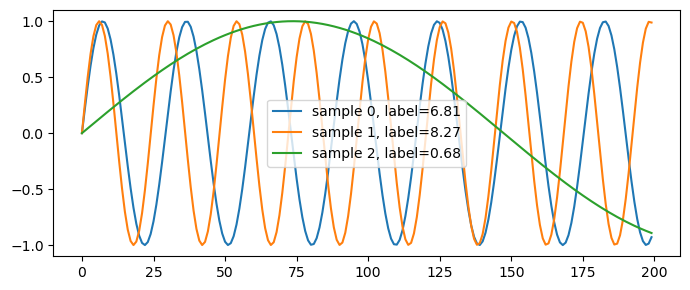

condition batch: (64, 1)
signal batch:    (64, 200)


In [38]:
dataset = SineWave_DataSet(freq_max=10, n_dim=200)
data_loader = DataLoader(dataset, batch_size=64, shuffle=True)

conditions, clean_batch = next(iter(data_loader))
plot_batched_lines(
    clean_batch[:3],
    conditions[:3],
    max_lines=3,
    figsize=(7, 3),
)

print("condition batch:", tuple(conditions.shape))
print("signal batch:   ", tuple(clean_batch.shape))

## Destroy/corrupt the clean sample

Take one clean sine wave and add a small random disturbance. Then do it again. After enough steps, the identity of the original curve disappears.

We choose the forward corruption rule, i.e., how to destroy a sample, carefully. It is designed to corrupt (add noise to) $x_0$, the original data, to the more noisy $x_1$, and then add noise to $x_1$ to get the more noisy $x_2$, and ...
The corruption rule is defined such that:

- We get to derive and know the probability distribution of $x_t$ given $x_0$. Importance: Given $x_0$, we can directly get a sample of $x_t$. There is no need to destroy the sample one step at a time in practice.
- When T is large enough, $x_T$ is approximating standard Gaussian noise (zero mean, identity covariance matrix). Importance: If $x_T$ is standard Gaussian noise, we can sample from it.
- **If we know $x_0$ and $x_t$, we know the exact and analytical probabilistic distribution of $x_{t-1}$ (the conditional distribution of $x_{t-1}$ given $x_0$ and $x_t$).**

This conditional distribution is derived analytically. This point is very important, but often gets buried in the derivations. It will be introduced more later. 
The mean of $x_{t-1}$ given ($x_0$, $x_t$) is a weighted sum of $x_0$ and $x_t$.

More specifically, the scheduler/schedule help defines the corruption rule. For example, it tells how strong the corruption should be at each of 500 steps. 


<p align="center">
  <img
    src="figs/relationship1b.png"
    alt="Known forward relationships and the missing reverse step"
    width="500"
  />
</p>


Why would we deliberately destroy the thing we want to generate?

Because the destruction process gives us training pairs for free. At any chosen noise level, we know:

- the clean signal we started from,
- the random noise we injected, and
- the noisy signal produced by combining them.

Nothing is learned in this direction. We control the experiment, so we know the answer to the denoising question before we ask the neural network.


In [29]:
## Generate the schedule. Each coefficient has a different value at each time step. 

T = 500
schedule = noise_scheduler(T=T)

for name, values in schedule.items():
    print(
        f"{name:32s} "
        f"shape={tuple(values.shape)}, "
    )

Adopting a linear scheduler
betas                            shape=(500,), 
alphas                           shape=(500,), 
alpha_hats                       shape=(500,), 
alpha_hats_sqrt                  shape=(500,), 
one_minus_alpha_hats_sqrt        shape=(500,), 
posterior_variance               shape=(500,), 


### One possible path from a signal to noise

The red curve is the original sine wave. The moving curve is one random corruption path. Early on, the underlying shape remains obvious. Later, local fluctuations dominate. Near the end, the sample looks almost like ordinary Gaussian noise.

![A sine wave being gradually corrupted by Gaussian noise](figs/destroy_sample.gif)

This animation is helpful, but it hides something important: it shows only one random outcome at each time. The forward process is not a single path. It is a probability distribution over many possible noisy signals.

## One animation hides a distribution

Choose one location on the curve—index 60—and keep the clean signal fixed. If we repeat the corruption experiment many times, that one location ends up with many different noisy values.

The histograms below show those repeated outcomes (i.e., generate the samples one step at a time). The smooth curves show the Gaussian distribution predicted directly by the forward process (from 0 directly to t). 

Why make this comparison? Because it reveals three facts that are easy to miss in an animation:

1. A noisy sample at a given timestep is one draw from a distribution (the distribution of $x_t$ given $x_0$), not a deterministic transformation.
2. Because of the deliberate construction of the schedulers, we can sample a late noisy state ($x_t$) directly at time step t; we do not need to simulate every earlier step during training.
3. At large timesteps, the value forgets the original signal and approaches standard Gaussian noise.

The schedule coefficients used to draw the smooth curves are intentionally left uninterpreted here. Only their effect matters.

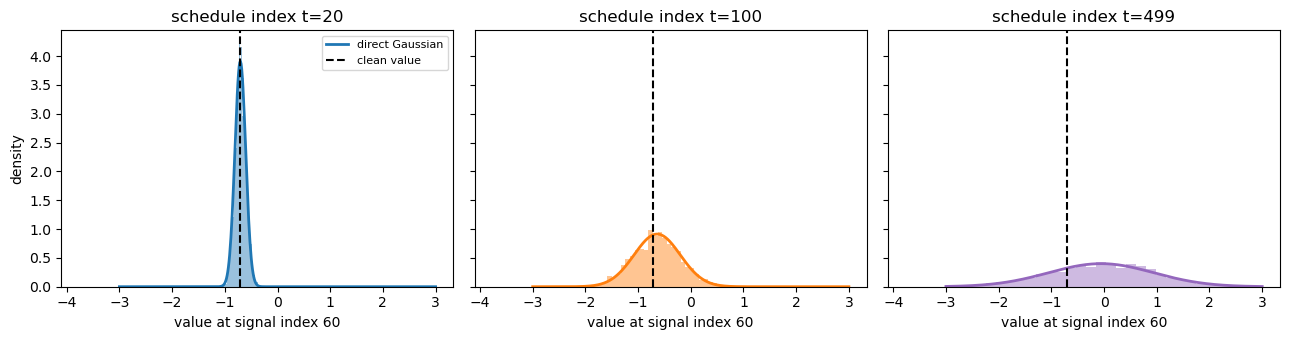

In [30]:
_, clean_signal = dataset[0]
clean_signal_batch = clean_signal.unsqueeze(0)
signal_index = 60
checkpoints = [20, 100, 499]
colors = ["tab:blue", "tab:orange", "tab:purple"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharex=True, sharey=True)
x_grid = np.linspace(-3, 3, 500)

for ax, t, color in zip(axes, checkpoints, colors):
    empirical_samples = add_noise_onestep_cum_sampler(
        clean_signal_batch,
        t,
        schedule,
        no_samples=2000,
    )

    observed = empirical_samples[:, signal_index].detach().cpu().numpy()
    expected_mean = (
        clean_signal[signal_index] * schedule["alpha_hats_sqrt"][t]
    ).item()
    expected_std = schedule["one_minus_alpha_hats_sqrt"][t].item()

    ax.hist(observed, bins=35, density=True, alpha=0.45, color=color)
    ax.plot(
        x_grid,
        norm.pdf(x_grid, loc=expected_mean, scale=expected_std),
        color=color,
        linewidth=2,
        label="direct Gaussian",
    )
    ax.axvline(
        clean_signal[signal_index].item(),
        color="black",
        linestyle="--",
        label="clean value",
    )
    ax.set_title(f"schedule index t={t}")
    ax.set_xlabel("value at signal index 60")

axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## The shortcut used during training

As we can get a sample of $x_t$ given $x_0$ directly. 
The forward process has a direct shortcut:

> noisy signal = scaled retained clean signal + scaled Gaussian noise

equivalently,

> $x_t$ = scaled $x_0$ + scaled Gaussian noise


The schedule supplies the two scale factors for the requested timestep. The important part is the relationship it creates: if we choose a clean signal, a timestep, and Gaussian noise, then given the scheduler we can construct the corresponding noisy signal immediately.

This also tells us why noise is such a convenient training target: we generated it ourselves, so the exact answer is available.

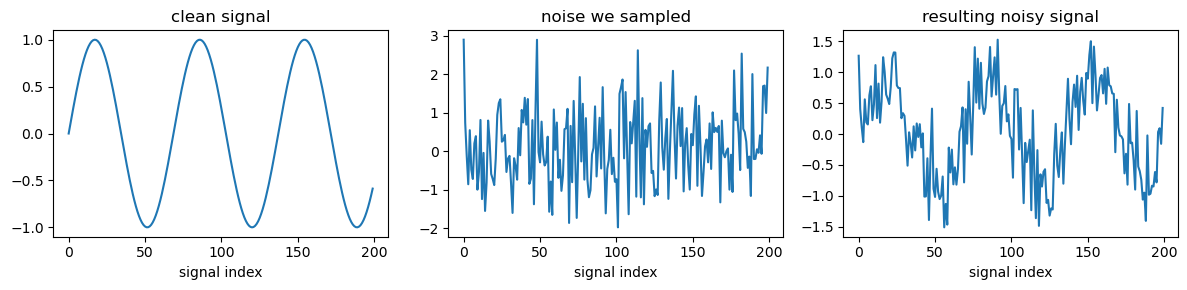

In [31]:
example_t = torch.tensor([100])
x_t_example, noise_example = add_noise_from_zero(
    clean_signal_batch,
    example_t,
    schedule,
)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)
axes[0].plot(clean_signal)
axes[0].set_title("clean signal")
axes[1].plot(noise_example[0])
axes[1].set_title("noise we sampled")
axes[2].plot(x_t_example[0])
axes[2].set_title("resulting noisy signal")

for ax in axes:
    ax.set_xlabel("signal index")

plt.tight_layout()
plt.show()

## The central problem appears when we reverse direction

During training, we know the clean signal ($x_0$) because it came from the dataset.

During generation, we start from noise ($x_t$ with $t$ being large). There is no hidden clean signal waiting for us to uncover. We have only the current noisy state ($x_t$), and we need to decide what a slightly cleaner state ($x_{t-1}$) should look like.

As mentioned earlier, if both the current noisy signal ($x_t$) and its original clean signal ($x_0$) were known, the probability distribution of the previous, slightly cleaner state ($x_{t-1}$) would be available analytically. But the clean signal ($x_0$) is exactly what generation does not have.

**That missing clean information is the gap the neural network must fill.**

The diagram below makes the gap visible. The forward and clean-conditioned relationships are available because we designed the corruption experiment ($x_0$ to $x_t$). How to go from $x_t$ to $x_{t-1}$ is what the neural network needs to learn.

<p align="center">
  <img
    src="figs/relationship1b.png"
    alt="Known forward relationships and the missing reverse step"
    width="500"
  />
</p>

## Why predict noise?

The direct corruption rule ties together three quantities:

- the clean signal ($x_0$),
- the noisy signal ($x_t$), and
- the Gaussian noise used to connect them.

Knowing any two tells us about the third. Therefore, estimating the noise from the noisy signal ($x_t$) also gives an estimate of the clean component (estimated $x_0$ given $x_t$) hidden inside it.

Adding the noise variable completes the useful bridge in the diagram: the network estimates noise from the current noisy state ($x_t$), and that estimate supplies the missing information about the clean component (the estimated $x_0$ given $x_t$).


This does **not** mean that the model recovers the one true original sample. At a high noise level ($t$ being large), many different clean sine waves could plausibly produce nearly the same noisy observation. A deterministic neural network trained with mean-squared error returns the conditional average of those possibilities.

At very high noise ($t$ being large), that average may be close to a flat line: average many sine waves with different frequencies and their positive and negative parts mostly cancel. As the sample becomes less noisy, fewer clean signals remain plausible, and the estimated clean component becomes more specific.

The model does not need to solve generation in one jump. It only needs to provide a useful local correction from the current state to a slightly cleaner one.

## The same curve can require different answers at different times

A small wiggle in an almost-clean signal may be noise that should be removed. The same-sized wiggle inside an extremely noisy signal may carry almost no useful information. The network therefore needs two inputs:

1. What does the current signal ($x_t$) look like?
2. How far along the corruption process are we (the time step)?

## Time embedding
Passing the timestep as a bare integer gives the network only one coordinate. A sinusoidal embedding turns that integer into many coordinates that change at different rates.

A useful analogy is a timestamp. One enormous count of seconds can identify a moment, but year, month, day, hour, minute, and second expose several scales at once. Sinusoidal embeddings provide a similar collection of fast and slow coordinates. The analogy is not a derivation; it is a way to see why a richer representation of one number can be useful.

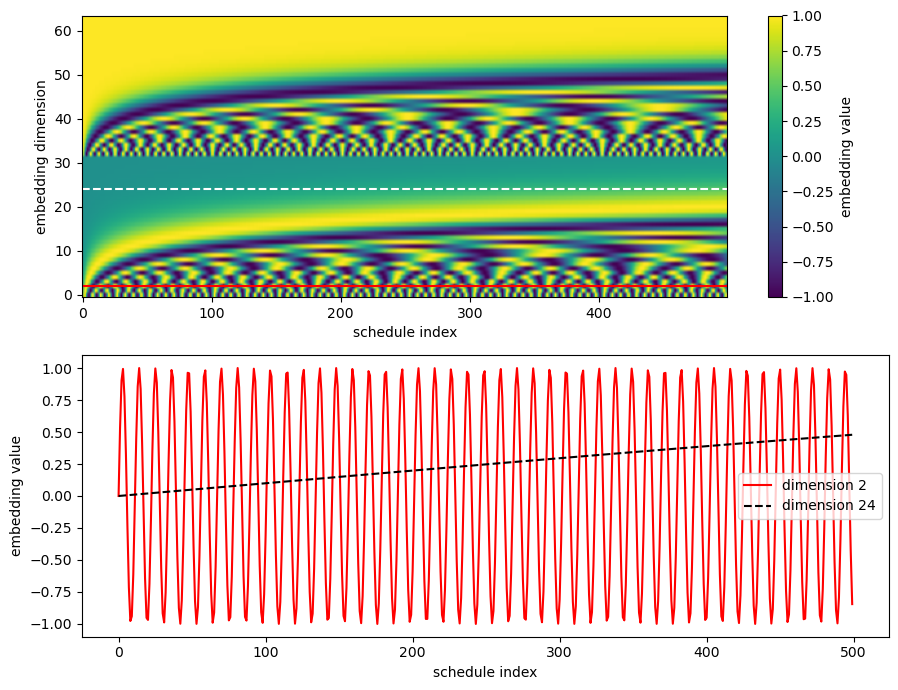

In [8]:
time_embedding_table = get_sinusoidal_table(t_steps=T, t_dim=64)
fast_dimension = 2
slow_dimension = 24

fig, axes = plt.subplots(2, 1, figsize=(9, 7))
image_handle = axes[0].imshow(
    time_embedding_table.T,
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
axes[0].axhline(fast_dimension, color="red")
axes[0].axhline(slow_dimension, color="white", linestyle="--")
axes[0].set_xlabel("schedule index")
axes[0].set_ylabel("embedding dimension")
fig.colorbar(image_handle, ax=axes[0], label="embedding value")

axes[1].plot(
    time_embedding_table[:, fast_dimension],
    color="red",
    label=f"dimension {fast_dimension}",
)
axes[1].plot(
    time_embedding_table[:, slow_dimension],
    color="black",
    linestyle="--",
    label=f"dimension {slow_dimension}",
)
axes[1].set_xlabel("schedule index")
axes[1].set_ylabel("embedding value")
axes[1].legend()

plt.tight_layout()
plt.show()

## The neural network is a noise estimator

The model used here is a small one-dimensional U-Net. Its architectural details are not the point of this notebook. What matters is its contract:

- Input 0: a noisy signal with shape `[batch, 1, 200]`.
- Input 1: one timestep per signal.
- input 2 (optional): a condition such as sine-wave frequency--Not used in this notebook
- Output: a tensor with exactly the same shape as the noisy signal, interpreted as predicted noise.

The U-Net sees local patterns at several resolutions. The timestep embedding is injected into its residual blocks so the same network can behave differently at different noise levels.

In [9]:
model = ConditionalUNet1D(
    in_channels=1,
    base_channels=64,
    t_steps=T,
    t_dim=64,
    cond_dim=1,
    emb_dim=72,
)

dummy_x_t = torch.randn(12, 1, 200)
dummy_t = torch.randint(0, T, (12,))

model.eval()
with torch.no_grad():
    dummy_prediction = model(dummy_x_t, dummy_t, None)

assert dummy_prediction.shape == dummy_x_t.shape
print("model input: ", tuple(dummy_x_t.shape))
print("model output:", tuple(dummy_prediction.shape))

model input:  (12, 1, 200)
model output: (12, 1, 200)


## Training: manufacture a question whose answer we know

For each clean batch, training performs the following experiment:

1. Give every signal (a sample from $x_0$) its own randomly selected timestep ($t$).
2. Give every signal its own Gaussian noise sample.
3. Construct the noisy signals ($x_t$) directly.
4. Ask the network to predict the sampled noise given $x_t$ and time step $t$.
5. Use mean-squared error between the true and predicted noise.

Why select different timesteps within the same batch? Because the final job spans the entire route from nearly clean data to nearly pure noise. A batch containing several noise levels gives a more representative training signal than a batch devoted to only one point on that route.

The cell below loads the included pretrained weights by default. Set `TRAIN_MODEL = True` to train from scratch instead.

In [35]:
TRAIN_MODEL = False
EPOCHS = 10
weights_path = Path("trained_parameters/unconditional.pt")

model = model.to(device)
schedule_device = {name: values.to(device) for name, values in schedule.items()}

if TRAIN_MODEL:
    loss_fn = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=5e-4)
    model.train()

    for epoch_index in range(EPOCHS):
        running_loss = 0.0

        for batch_index, (_, x_clean_batch) in enumerate(data_loader):
            x_clean_batch = x_clean_batch.to(device)
            t_batch = torch.randint(
                0,
                T,
                (x_clean_batch.shape[0],),
                device=device,
            )

            x_t_batch, target_noise = add_noise_from_zero(
                x_clean_batch,
                t_batch,
                schedule_device,
                device,
            )
            x_t_batch = x_t_batch.unsqueeze(1)
            target_noise = target_noise.unsqueeze(1)

            optimizer.zero_grad()
            predicted_noise = model(x_t_batch, t_batch, None)
            loss = loss_fn(predicted_noise, target_noise)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        mean_loss = running_loss / len(data_loader)
        print(f"epoch {epoch_index + 1:02d}: mean loss={mean_loss:.6f}")
else:
    state_dict = torch.load(weights_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    print(f"Loaded pretrained weights from {weights_path}.")

model.eval()

Loaded pretrained weights from trained_parameters/unconditional.pt.


ConditionalUNet1D(
  (cond_embed): ConditionEmbedding(
    (time_proj): Sequential(
      (0): Linear(in_features=64, out_features=72, bias=True)
      (1): SiLU()
      (2): Linear(in_features=72, out_features=72, bias=True)
    )
    (cond_proj): Sequential(
      (0): Linear(in_features=1, out_features=72, bias=True)
      (1): SiLU()
      (2): Linear(in_features=72, out_features=72, bias=True)
    )
  )
  (in_conv): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (down1): ResBlock1D_conditional(
    (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (act): SiLU()
    (emb_proj): Linear(in_features=72, out_features=64, bias=True)
    (skip): Identity()
  )
  (pool1): Conv1d(64, 128, kernel_size=(4,), stride=(2,), padding=(1,))
  (down2): ResBlock1D_conditional(
    (con

## Generation: repetition does the work

Training started with a real signal and created a noisy question. Generation has no real signal. It starts from a fresh Gaussian-noise sample.

At every reverse step, the model predicts the noise present in the current state. That prediction supplies an estimate of the clean component (the estimated $x_0$ given $x_t$), which in turn tells the sampler where a slightly cleaner state ($x_{t-1}$) should be centered. A small amount of randomness is added as prescribed by the reverse process, and the procedure repeats.

No individual step needs to invent a whole sine wave. Each step only needs to improve the current sample locally.

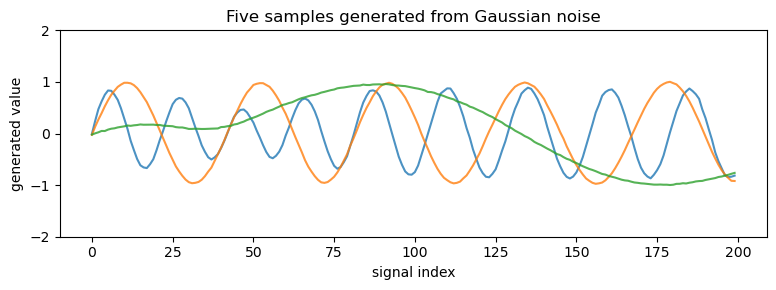

In [ ]:
torch.manual_seed(11)

generated = ddpm_sampler(
    sample_dim=200,
    n_sample=5,
    noise_dict=schedule_device,
    model=model,
    device=device,
)

plt.figure(figsize=(8, 3))
for sample in generated:
    plt.plot(sample[0].detach().cpu(), alpha=0.8)

plt.xlabel("signal index")
plt.ylabel("generated value")
plt.title("Five samples generated from Gaussian noise")
plt.ylim(-2, 2)
plt.tight_layout()
plt.show()

## A clarification: the estimated clean mean (estimated $x_0$ given $x_t$) is not the final sample

It is tempting to ask: if predicting noise gives us an estimate of the clean signal, why not stop there?

At a noisy timestep, the estimate (estimated $x_0$ given $x_t$) is a conditional mean over many clean signals that could explain the current noisy $x_t$. It is guidance for the next small reverse step, not necessarily a plausible sample by itself.

The first animation follows the actual reverse sample. The second follows the clean conditional-mean estimate made at each reverse step.

### Reverse sample

![The reverse sample evolving from noise to a sine wave](figs/unconditional_each_step.gif)

### Estimated clean conditional mean

![The estimated clean conditional mean during reverse diffusion](figs/unconditional_post_x0.gif)

Early in generation, the conditional mean is close to flat because many frequencies are still plausible and their average cancels. Later, enough large-scale structure survives in the current state to narrow the possibilities, so the estimate begins to resemble the final sine wave.

This happens unusually early in our example because the data distribution is extremely simple. A rough up-and-down trend can already reveal a great deal about a sine wave. The same visual behavior should not be assumed for a complicated image distribution.

## What to keep in mind

- The forward process is useful because it manufactures supervised training targets.
- One forward animation is only one path through a family of conditional distributions.
- Training uses a direct jump to any timestep; repeated forward corruption is only needed for illustration.
- Predicting noise indirectly estimates the clean component (estimated $x_0$ given $x_t$) hidden in a noisy sample ($x_t$).
- That estimate (estimated $x_0$ given $x_t$) is a conditional mean, not a recovered ground-truth sample.
- The timestep tells one shared network what noise regime it is currently handling.
- Generation succeeds through many modest local corrections rather than one heroic prediction.

## What is intentionally skipped

The following topics matter, but they are omitted here because they interrupt the main intuition:

- the definition of the schedule coefficients,
- algebraic relationships among schedule quantities,
- the ELBO derivation of the noise-prediction objective,
- alternative choices for the reverse variance,
- detailed U-Net architecture design, and
- faster samplers such as DDIM.

These are natural next topics once the forward experiment, the noise target, and the repeated reverse correction all feel conceptually connected.

## References

- Ho, Jain, and Abbeel, *Denoising Diffusion Probabilistic Models* (2020)
- Hugging Face, *The Annotated Diffusion Model*
- Lilian Weng, *What are Diffusion Models?*
- Qingyuan Yang, [*Diffusion model (DDPM) explained by someone who is not Michael Jordan*](https://appendixafiga1b.substack.com/p/the-confession-of-the-confusions)